# 03 — Strategic Exploratory Data Analysis (EDA)

**Sector:** Aviation / Transportation  
**Project:** US Flight Ops Dashboard (Capstone 2)  
**Objective:** Transform raw observations into business intelligence. Identify operational bottlenecks and carrier performance tiers.

---

## 3.1 Setup & Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded.")

Libraries loaded.


In [19]:
# Auto-detect processed data path
def find_processed_path():
    candidates = [
        '../data/processed/',
        'data/processed/',
        './'
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, 'flights_cleaned.csv')):
            print(f"Data found at: {os.path.abspath(path)}")
            return path
    raise FileNotFoundError("Could not find flights_cleaned.csv. Run 02_cleaning.ipynb first.")

PROCESSED_PATH = find_processed_path()

print("Loading cleaned flights data...")
df = pd.read_csv(f'{PROCESSED_PATH}flights_cleaned.csv', low_memory=False)
df['DATE'] = pd.to_datetime(df['DATE'])

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")

Data found at: /Users/yashraghubanshi/Downloads/dva/data/processed
Loading cleaned flights data...
Loaded: 100,000 rows x 61 columns
Date range: 2015-01-01 to 2015-12-31


## 3.2 KPI Dashboard — Overall Performance Snapshot

In [20]:
# Compute key performance indicators
total_flights = len(df)
cancelled = df['CANCELLED'].sum()
diverted = df['DIVERTED'].sum()
non_cancelled = df[df['CANCELLED'] == 0]

avg_dep_delay = non_cancelled['DEPARTURE_DELAY'].mean()
avg_arr_delay = non_cancelled['ARRIVAL_DELAY'].mean()
median_arr_delay = non_cancelled['ARRIVAL_DELAY'].median()
on_time_rate = (non_cancelled['ARRIVAL_DELAY'] <= 15).mean() * 100
delay_rate = (non_cancelled['ARRIVAL_DELAY'] > 15).mean() * 100
cancellation_rate = cancelled / total_flights * 100

print("=" * 70)
print("         US AVIATION 2015 — KEY PERFORMANCE INDICATORS")
print("=" * 70)
print(f"  Total Flights:            {total_flights:>12,}")
print(f"  Cancelled Flights:        {cancelled:>12,} ({cancellation_rate:.2f}%)")
print(f"  Diverted Flights:         {diverted:>12,} ({diverted/total_flights*100:.2f}%)")
print(f"  On-Time Rate (<=15min):   {on_time_rate:>11.2f}%")
print(f"  Delay Rate (>15min):      {delay_rate:>11.2f}%")
print(f"  Avg Departure Delay:      {avg_dep_delay:>11.2f} min")
print(f"  Avg Arrival Delay:        {avg_arr_delay:>11.2f} min")
print(f"  Median Arrival Delay:     {median_arr_delay:>11.2f} min")
print("=" * 70)

         US AVIATION 2015 — KEY PERFORMANCE INDICATORS
  Total Flights:                 100,000
  Cancelled Flights:               1,554 (1.55%)
  Diverted Flights:                  251 (0.25%)
  On-Time Rate (<=15min):         81.77%
  Delay Rate (>15min):            17.97%
  Avg Departure Delay:             9.35 min
  Avg Arrival Delay:               4.42 min
  Median Arrival Delay:           -5.00 min


## 3.3 Temporal Analysis — Monthly Trends

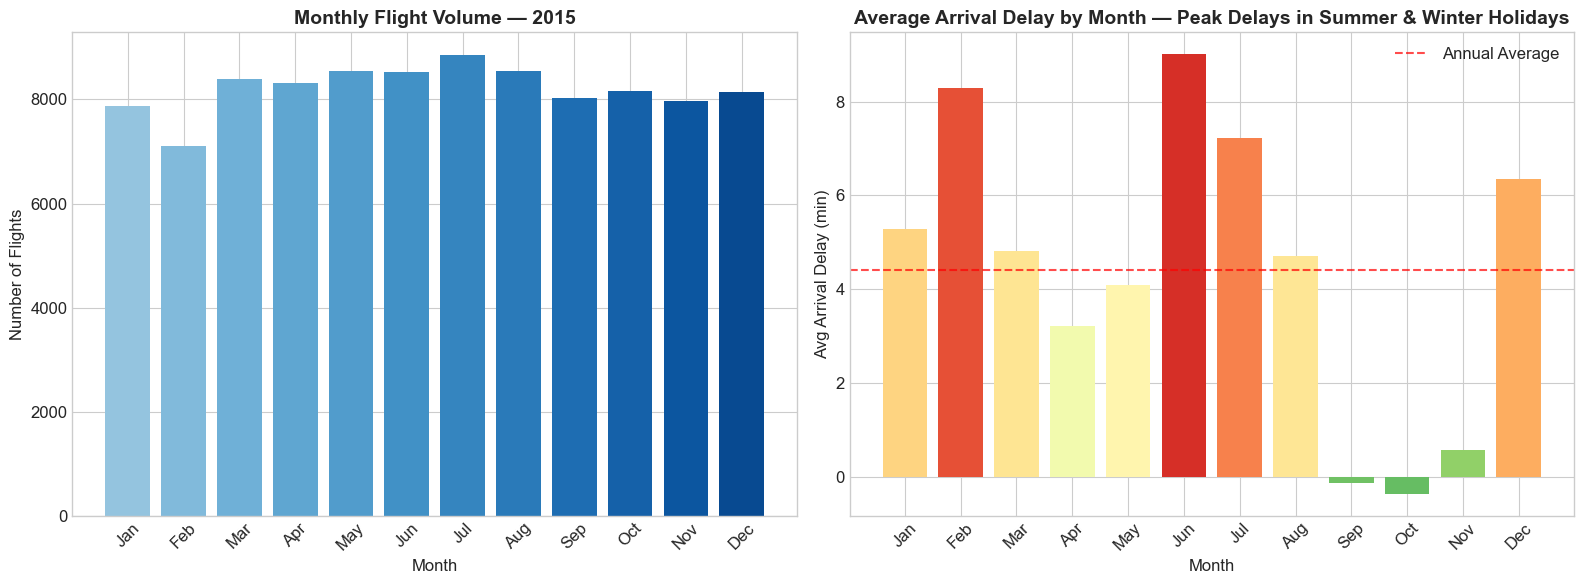


Insight: Summer months (Jun-Aug) and winter holidays (Dec-Feb) show highest average delays.


In [21]:
# Monthly flight volume and delay rate
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_stats = non_cancelled.groupby('MONTH').agg(
    flight_count=('FLIGHT_NUMBER', 'count'),
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean'),
    avg_dep_delay=('DEPARTURE_DELAY', 'mean')
).reset_index()

monthly_stats['delay_rate'] = monthly_stats['delay_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flight volume by month
colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, 12))
axes[0].bar(monthly_stats['MONTH'], monthly_stats['flight_count'], color=colors1)
axes[0].set_title('Monthly Flight Volume — 2015', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Flights')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45)

# Average delay by month
color_vals = monthly_stats['avg_delay'].values
colors2 = plt.cm.RdYlGn_r(np.interp(color_vals, [color_vals.min(), color_vals.max()], [0.2, 0.9]))
axes[1].bar(monthly_stats['MONTH'], monthly_stats['avg_delay'], color=colors2)
axes[1].axhline(y=monthly_stats['avg_delay'].mean(), color='red', linestyle='--', alpha=0.7, label='Annual Average')
axes[1].set_title('Average Arrival Delay by Month — Peak Delays in Summer & Winter Holidays', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Arrival Delay (min)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()
print("\nInsight: Summer months (Jun-Aug) and winter holidays (Dec-Feb) show highest average delays.")

## 3.4 Day-of-Week Analysis

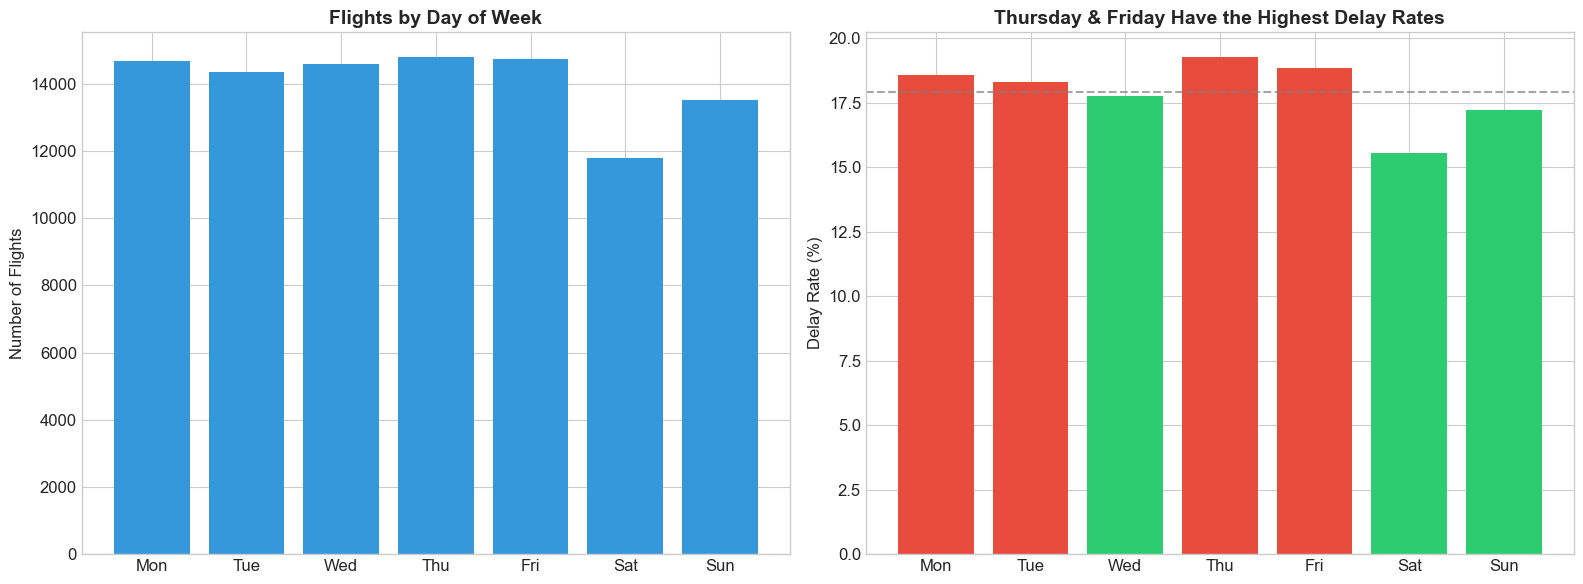


Insight: Weekdays (Thu-Fri) have higher delay rates; Saturdays have the lowest.


In [22]:
# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_stats = non_cancelled.groupby('DAY_OF_WEEK').agg(
    flight_count=('FLIGHT_NUMBER', 'count'),
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

dow_stats['delay_rate_pct'] = dow_stats['delay_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flight volume by day of week
axes[0].bar(dow_stats['DAY_OF_WEEK'], dow_stats['flight_count'], color='#3498db')
axes[0].set_title('Flights by Day of Week', fontweight='bold')
axes[0].set_xticks(range(1, 8))
axes[0].set_xticklabels([d[:3] for d in day_order])
axes[0].set_ylabel('Number of Flights')

# Delay rate by day of week
bars = axes[1].bar(dow_stats['DAY_OF_WEEK'], dow_stats['delay_rate_pct'], 
                   color=['#e74c3c' if x > dow_stats['delay_rate_pct'].mean() else '#2ecc71' for x in dow_stats['delay_rate_pct']])
axes[1].axhline(y=dow_stats['delay_rate_pct'].mean(), color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Thursday & Friday Have the Highest Delay Rates', fontweight='bold')
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_ylabel('Delay Rate (%)')

plt.tight_layout()
plt.show()
print("\nInsight: Weekdays (Thu-Fri) have higher delay rates; Saturdays have the lowest.")

## 3.5 Hourly Departure Pattern

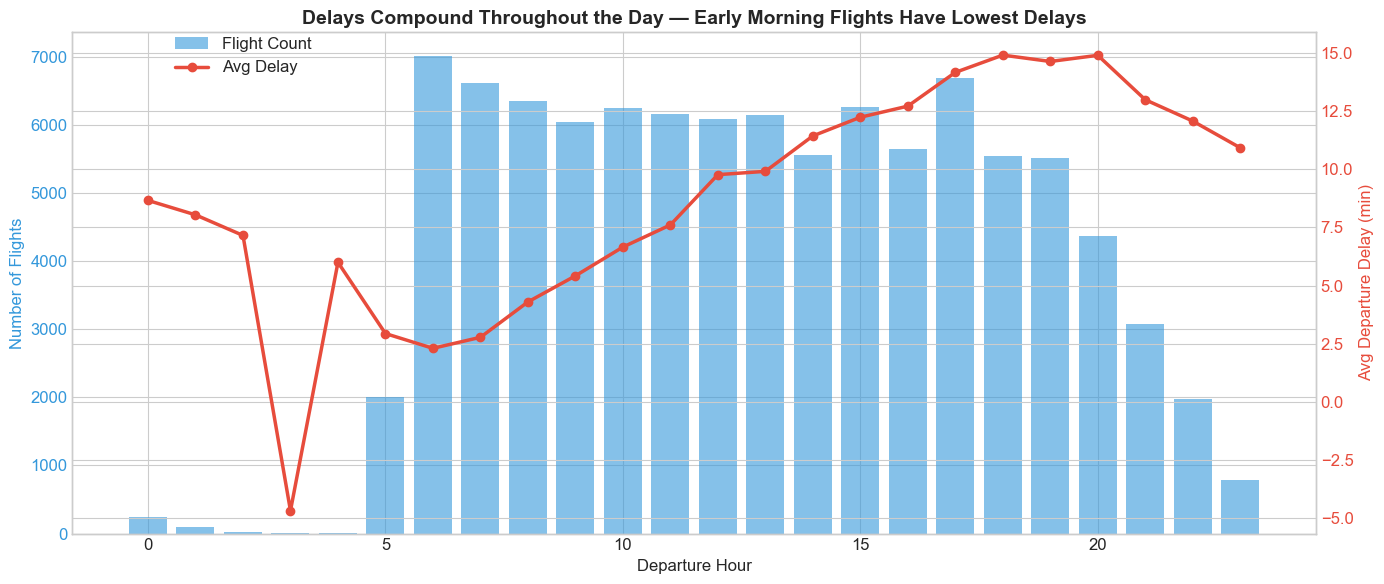


Insight: Delays compound throughout the day. Early departures (5-8 AM) are most punctual. Late evening flights (after 6 PM) face cascading delays.


In [23]:
# Hourly departure delay pattern
hourly_stats = non_cancelled.groupby('DEP_HOUR').agg(
    flight_count=('FLIGHT_NUMBER', 'count'),
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

hourly_stats['delay_rate_pct'] = hourly_stats['delay_rate'] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#3498db'
color2 = '#e74c3c'

ax1.bar(hourly_stats['DEP_HOUR'], hourly_stats['flight_count'], color=color1, alpha=0.6, label='Flight Count')
ax1.set_xlabel('Departure Hour')
ax1.set_ylabel('Number of Flights', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(hourly_stats['DEP_HOUR'], hourly_stats['avg_delay'], color=color2, linewidth=2.5, marker='o', label='Avg Delay')
ax2.set_ylabel('Avg Departure Delay (min)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Delays Compound Throughout the Day — Early Morning Flights Have Lowest Delays', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()
print("\nInsight: Delays compound throughout the day. Early departures (5-8 AM) are most punctual. Late evening flights (after 6 PM) face cascading delays.")

## 3.6 Airline Performance Comparison

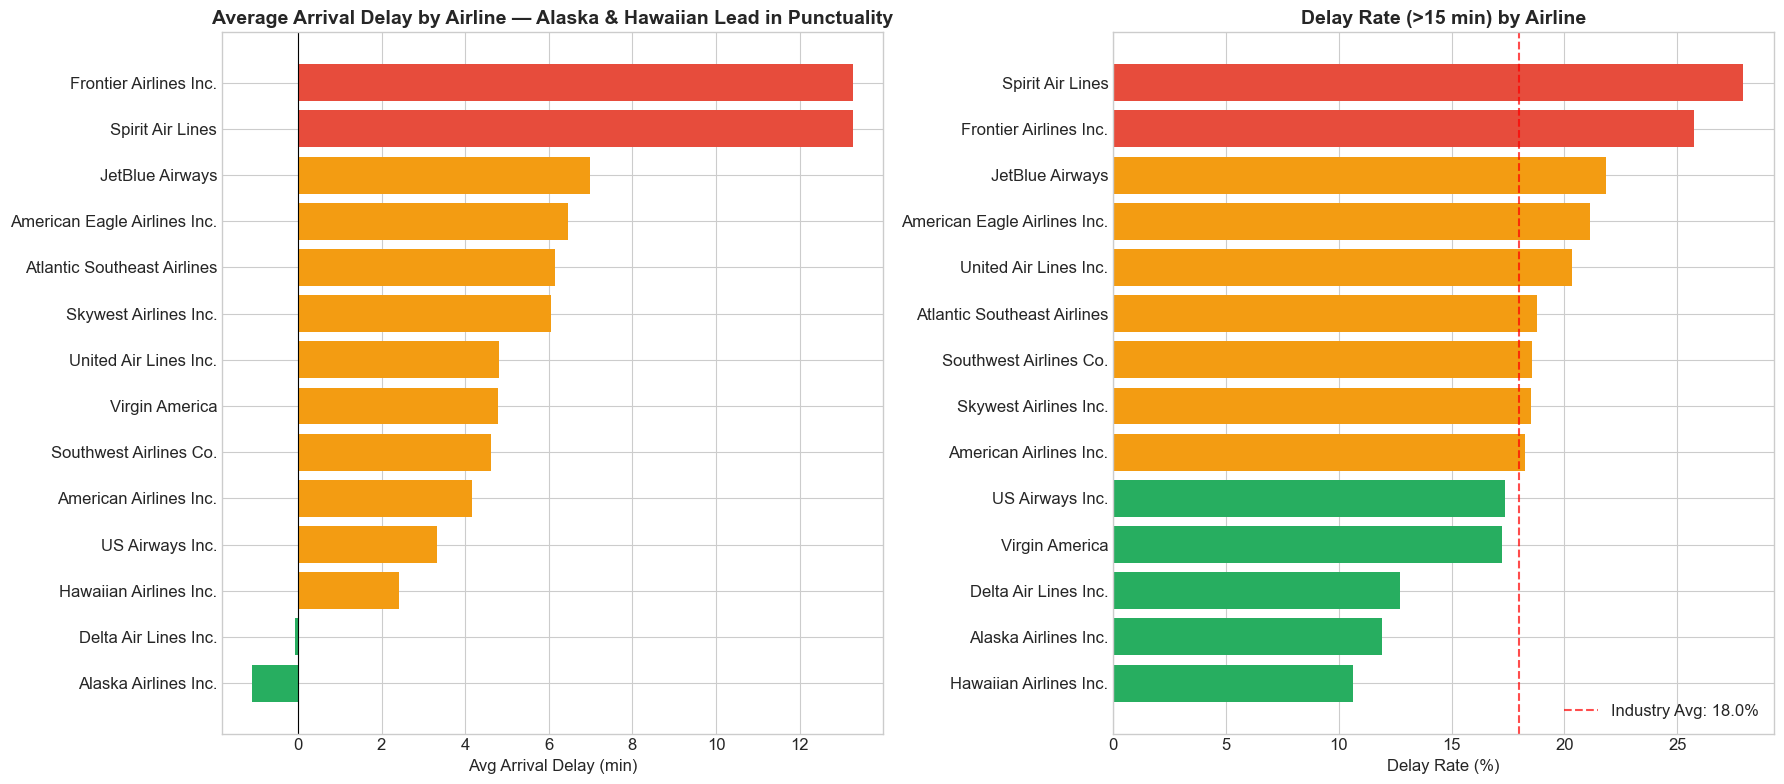


Insight: Low-cost and regional carriers tend to have higher delay rates. Alaska Airlines and Hawaiian Airlines outperform the industry average significantly.


In [24]:
# Airline performance ranking
airline_stats = non_cancelled.groupby(['AIRLINE', 'AIRLINE_NAME']).agg(
    total_flights=('FLIGHT_NUMBER', 'count'),
    avg_arr_delay=('ARRIVAL_DELAY', 'mean'),
    median_arr_delay=('ARRIVAL_DELAY', 'median'),
    delay_rate=('IS_DELAYED', 'mean'),
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    cancelled_count=('CANCELLED', 'sum')
).reset_index()

airline_stats['delay_rate_pct'] = airline_stats['delay_rate'] * 100
airline_stats = airline_stats.sort_values('avg_arr_delay', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Average arrival delay by airline
colors = ['#27ae60' if x < 0 else '#e74c3c' if x > 10 else '#f39c12' for x in airline_stats['avg_arr_delay']]
axes[0].barh(airline_stats['AIRLINE_NAME'], airline_stats['avg_arr_delay'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Average Arrival Delay by Airline — Alaska & Hawaiian Lead in Punctuality', fontweight='bold')
axes[0].set_xlabel('Avg Arrival Delay (min)')

# Delay rate by airline
airline_sorted_rate = airline_stats.sort_values('delay_rate_pct', ascending=True)
colors2 = ['#27ae60' if x < 18 else '#e74c3c' if x > 25 else '#f39c12' for x in airline_sorted_rate['delay_rate_pct']]
axes[1].barh(airline_sorted_rate['AIRLINE_NAME'], airline_sorted_rate['delay_rate_pct'], color=colors2)
axes[1].axvline(x=delay_rate, color='red', linestyle='--', alpha=0.7, label=f'Industry Avg: {delay_rate:.1f}%')
axes[1].set_title('Delay Rate (>15 min) by Airline', fontweight='bold')
axes[1].set_xlabel('Delay Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInsight: Low-cost and regional carriers tend to have higher delay rates. Alaska Airlines and Hawaiian Airlines outperform the industry average significantly.")

## 3.7 Top 20 Busiest Airports — Delay Analysis

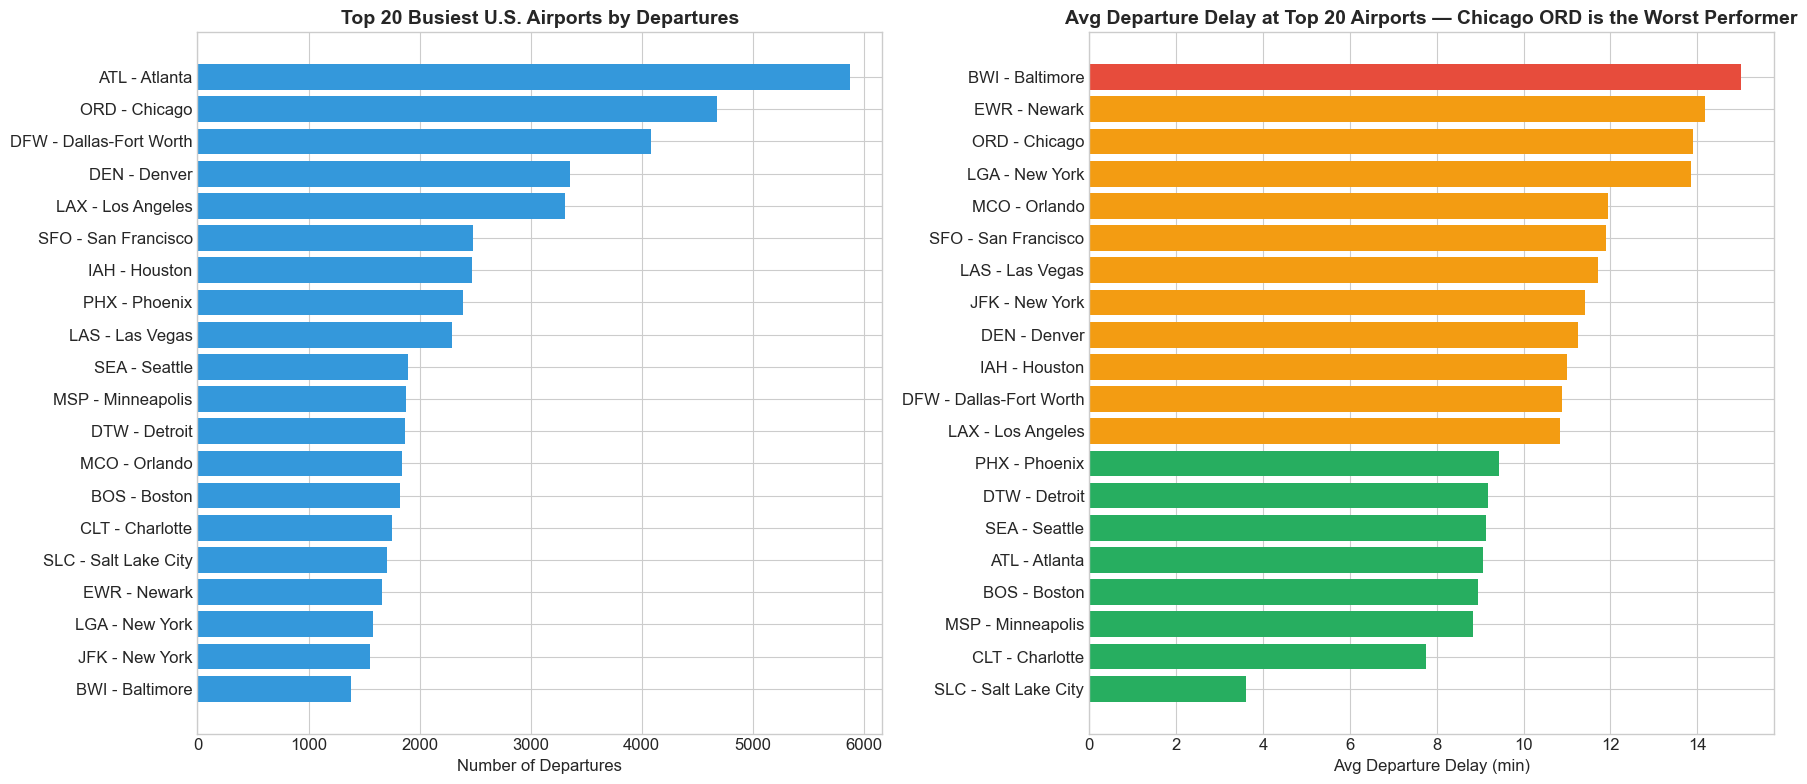


Insight: ATL (Atlanta) handles the most flights but has moderate delays. Major hubs like ORD (Chicago) and EWR (Newark) have disproportionately high delays.


In [25]:
# Airport analysis — top 20 by flight volume
origin_stats = non_cancelled.groupby(['ORIGIN_AIRPORT', 'ORIGIN_CITY', 'ORIGIN_STATE']).agg(
    departures=('FLIGHT_NUMBER', 'count'),
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

top20_airports = origin_stats.nlargest(20, 'departures')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Flight volume
top20_sorted = top20_airports.sort_values('departures', ascending=True)
axes[0].barh(top20_sorted['ORIGIN_AIRPORT'] + ' - ' + top20_sorted['ORIGIN_CITY'].fillna(''), 
             top20_sorted['departures'], color='#3498db')
axes[0].set_title('Top 20 Busiest U.S. Airports by Departures', fontweight='bold')
axes[0].set_xlabel('Number of Departures')

# Average delay at top airports
top20_by_delay = top20_airports.sort_values('avg_dep_delay', ascending=True)
colors = ['#e74c3c' if x > 15 else '#f39c12' if x > 10 else '#27ae60' for x in top20_by_delay['avg_dep_delay']]
axes[1].barh(top20_by_delay['ORIGIN_AIRPORT'] + ' - ' + top20_by_delay['ORIGIN_CITY'].fillna(''), 
             top20_by_delay['avg_dep_delay'], color=colors)
axes[1].set_title('Avg Departure Delay at Top 20 Airports — Chicago ORD is the Worst Performer', fontweight='bold')
axes[1].set_xlabel('Avg Departure Delay (min)')

plt.tight_layout()
plt.show()
print("\nInsight: ATL (Atlanta) handles the most flights but has moderate delays. Major hubs like ORD (Chicago) and EWR (Newark) have disproportionately high delays.")

## 3.8 Delay Type Distribution

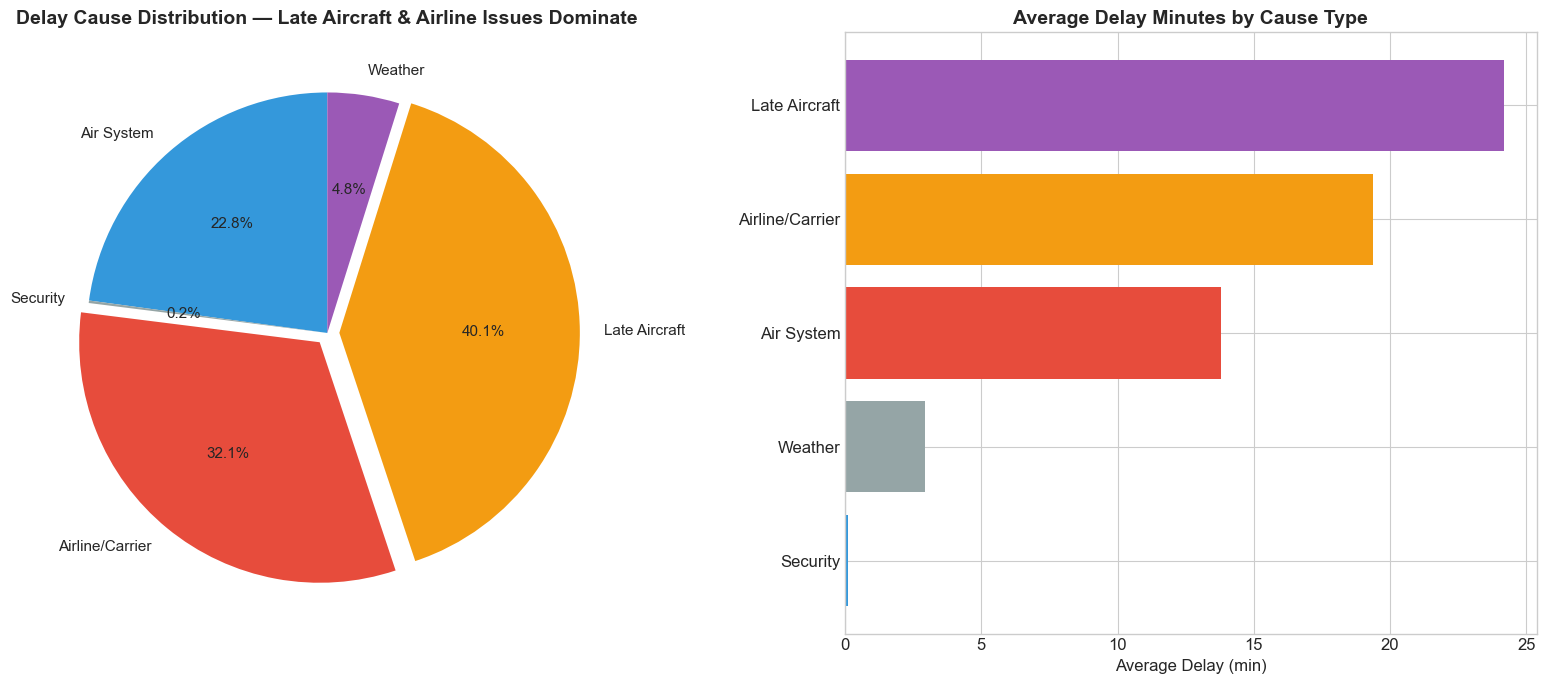


Insight: Late Aircraft (cascading delays) and Airline-caused delays together account for the majority of delay minutes, suggesting fleet and scheduling optimization as key levers.


In [26]:
# Delay type distribution (for delayed flights only)
delayed_flights = non_cancelled[non_cancelled['ARRIVAL_DELAY'] > 15]

delay_type_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                   'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_type_labels = ['Air System', 'Security', 'Airline/Carrier', 'Late Aircraft', 'Weather']

delay_totals = delayed_flights[delay_type_cols].sum()
delay_totals.index = delay_type_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
colors_pie = ['#3498db', '#95a5a6', '#e74c3c', '#f39c12', '#9b59b6']
explode = (0, 0, 0.05, 0.05, 0)
wedges, texts, autotexts = axes[0].pie(delay_totals, labels=delay_totals.index, 
                                        autopct='%1.1f%%', colors=colors_pie,
                                        explode=explode, startangle=90,
                                        textprops={'fontsize': 11})
axes[0].set_title('Delay Cause Distribution — Late Aircraft & Airline Issues Dominate', fontweight='bold')

# Bar chart — average delay minutes by cause
avg_by_cause = delayed_flights[delay_type_cols].mean()
avg_by_cause.index = delay_type_labels
avg_by_cause = avg_by_cause.sort_values(ascending=True)
axes[1].barh(avg_by_cause.index, avg_by_cause.values, color=colors_pie)
axes[1].set_title('Average Delay Minutes by Cause Type', fontweight='bold')
axes[1].set_xlabel('Average Delay (min)')

plt.tight_layout()
plt.show()
print("\nInsight: Late Aircraft (cascading delays) and Airline-caused delays together account for the majority of delay minutes, suggesting fleet and scheduling optimization as key levers.")

## 3.9 Cancellation Analysis

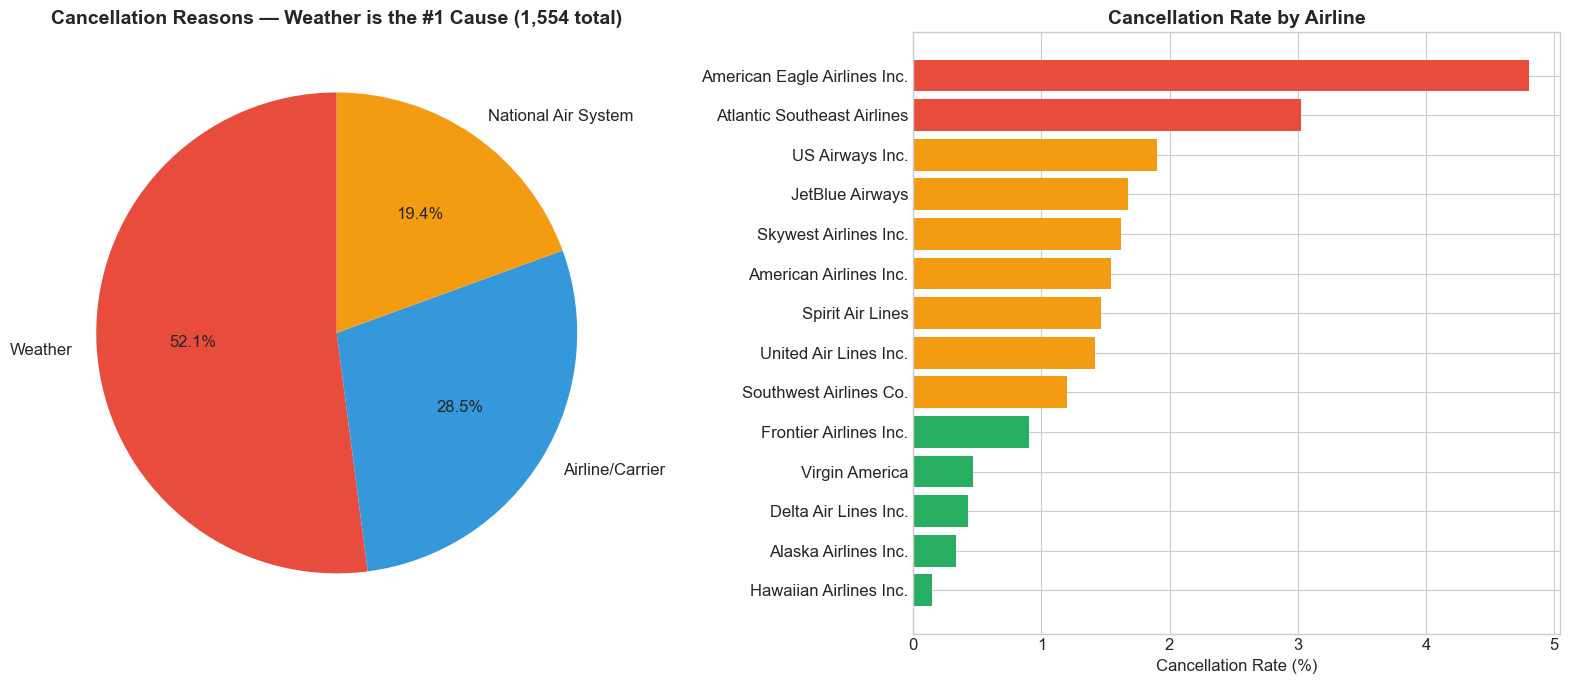


Insight: Weather is the primary driver of cancellations, but airline-specific factors vary significantly — some carriers cancel at 3x the rate of others.


In [27]:
# Cancellation analysis
cancelled_df = df[df['CANCELLED'] == 1]

# Cancellation by reason
cancel_reasons = cancelled_df['CANCELLATION_REASON_DESC'].value_counts()

# Cancellation by airline
cancel_by_airline = df.groupby('AIRLINE_NAME')['CANCELLED'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Cancellation reasons
colors_cancel = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
cancel_reasons_filtered = cancel_reasons[cancel_reasons.index != 'Not Cancelled']
axes[0].pie(cancel_reasons_filtered, labels=cancel_reasons_filtered.index, 
            autopct='%1.1f%%', colors=colors_cancel, startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(f'Cancellation Reasons — Weather is the #1 Cause ({cancelled:,} total)', fontweight='bold')

# Cancellation rate by airline
cancel_by_airline_sorted = cancel_by_airline.sort_values(ascending=True)
colors_bar = ['#e74c3c' if x > 2 else '#f39c12' if x > 1 else '#27ae60' for x in cancel_by_airline_sorted]
axes[1].barh(cancel_by_airline_sorted.index, cancel_by_airline_sorted.values, color=colors_bar)
axes[1].set_title('Cancellation Rate by Airline', fontweight='bold')
axes[1].set_xlabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()
print("\nInsight: Weather is the primary driver of cancellations, but airline-specific factors vary significantly — some carriers cancel at 3x the rate of others.")

## 3.10 Distance vs. Delay Relationship

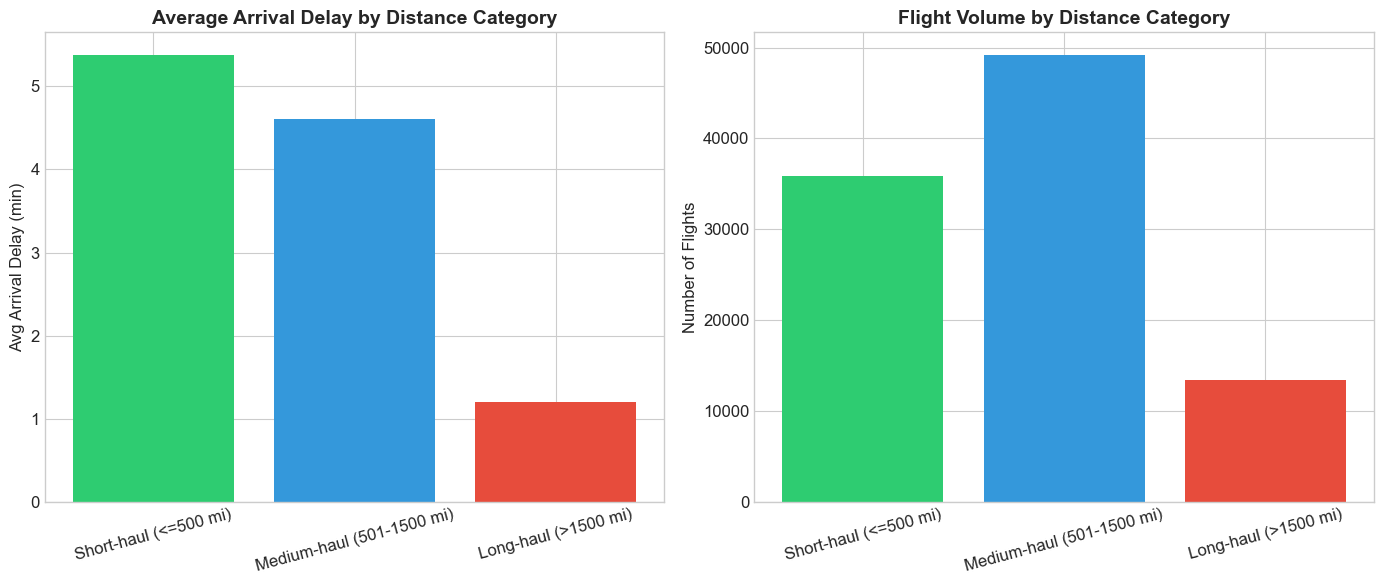


Insight: Short-haul flights dominate volume and experience comparable delay rates to long-haul, suggesting ground operations (turnaround) are a major factor, not air time.


In [28]:
# Distance vs Delay
dist_delay = non_cancelled.groupby('DISTANCE_CATEGORY').agg(
    flight_count=('FLIGHT_NUMBER', 'count'),
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

dist_delay['delay_rate_pct'] = dist_delay['delay_rate'] * 100

# Reorder
dist_order = ['Short-haul (<=500 mi)', 'Medium-haul (501-1500 mi)', 'Long-haul (>1500 mi)']
dist_delay['DISTANCE_CATEGORY'] = pd.Categorical(dist_delay['DISTANCE_CATEGORY'], categories=dist_order, ordered=True)
dist_delay = dist_delay.sort_values('DISTANCE_CATEGORY')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_dist = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(range(len(dist_delay)), dist_delay['avg_delay'], color=colors_dist[:len(dist_delay)])
axes[0].set_title('Average Arrival Delay by Distance Category', fontweight='bold')
axes[0].set_xticks(range(len(dist_delay)))
axes[0].set_xticklabels(dist_delay['DISTANCE_CATEGORY'].tolist(), rotation=15)
axes[0].set_ylabel('Avg Arrival Delay (min)')

axes[1].bar(range(len(dist_delay)), dist_delay['flight_count'], color=colors_dist[:len(dist_delay)])
axes[1].set_title('Flight Volume by Distance Category', fontweight='bold')
axes[1].set_xticks(range(len(dist_delay)))
axes[1].set_xticklabels(dist_delay['DISTANCE_CATEGORY'].tolist(), rotation=15)
axes[1].set_ylabel('Number of Flights')

plt.tight_layout()
plt.show()
print("\nInsight: Short-haul flights dominate volume and experience comparable delay rates to long-haul, suggesting ground operations (turnaround) are a major factor, not air time.")

## 3.11 Delay Distribution — Histogram

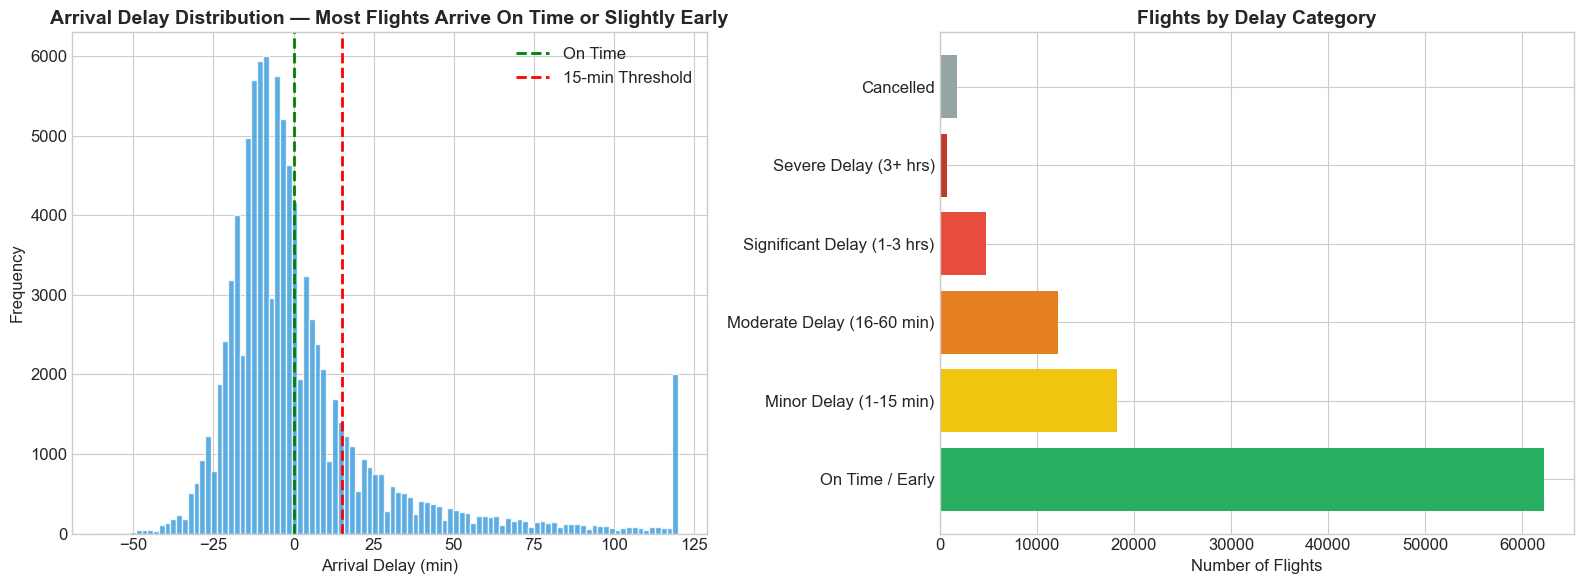


Insight: The distribution is right-skewed — most flights are on time, but the tail of severely delayed flights disproportionately impacts passenger experience and operational costs.


In [29]:
# Arrival delay distribution (excluding cancelled, capped for visibility)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full distribution (capped at -60 to 120 for readability)
delay_data = non_cancelled['ARRIVAL_DELAY'].dropna()
delay_capped = delay_data.clip(-60, 120)

axes[0].hist(delay_capped, bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='green', linewidth=2, linestyle='--', label='On Time')
axes[0].axvline(x=15, color='red', linewidth=2, linestyle='--', label='15-min Threshold')
axes[0].set_title('Arrival Delay Distribution — Most Flights Arrive On Time or Slightly Early', fontweight='bold')
axes[0].set_xlabel('Arrival Delay (min)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Delay category distribution
delay_cat_order = ['On Time / Early', 'Minor Delay (1-15 min)', 'Moderate Delay (16-60 min)', 
                   'Significant Delay (1-3 hrs)', 'Severe Delay (3+ hrs)', 'Cancelled']
delay_cats = df['DELAY_CATEGORY'].value_counts().reindex(delay_cat_order).dropna()
colors_cat = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#95a5a6']
axes[1].barh(delay_cats.index, delay_cats.values, color=colors_cat[:len(delay_cats)])
axes[1].set_title('Flights by Delay Category', fontweight='bold')
axes[1].set_xlabel('Number of Flights')

plt.tight_layout()
plt.show()

print("\nInsight: The distribution is right-skewed — most flights are on time, but the tail of severely delayed flights disproportionately impacts passenger experience and operational costs.")

## 3.12 Correlation Heatmap

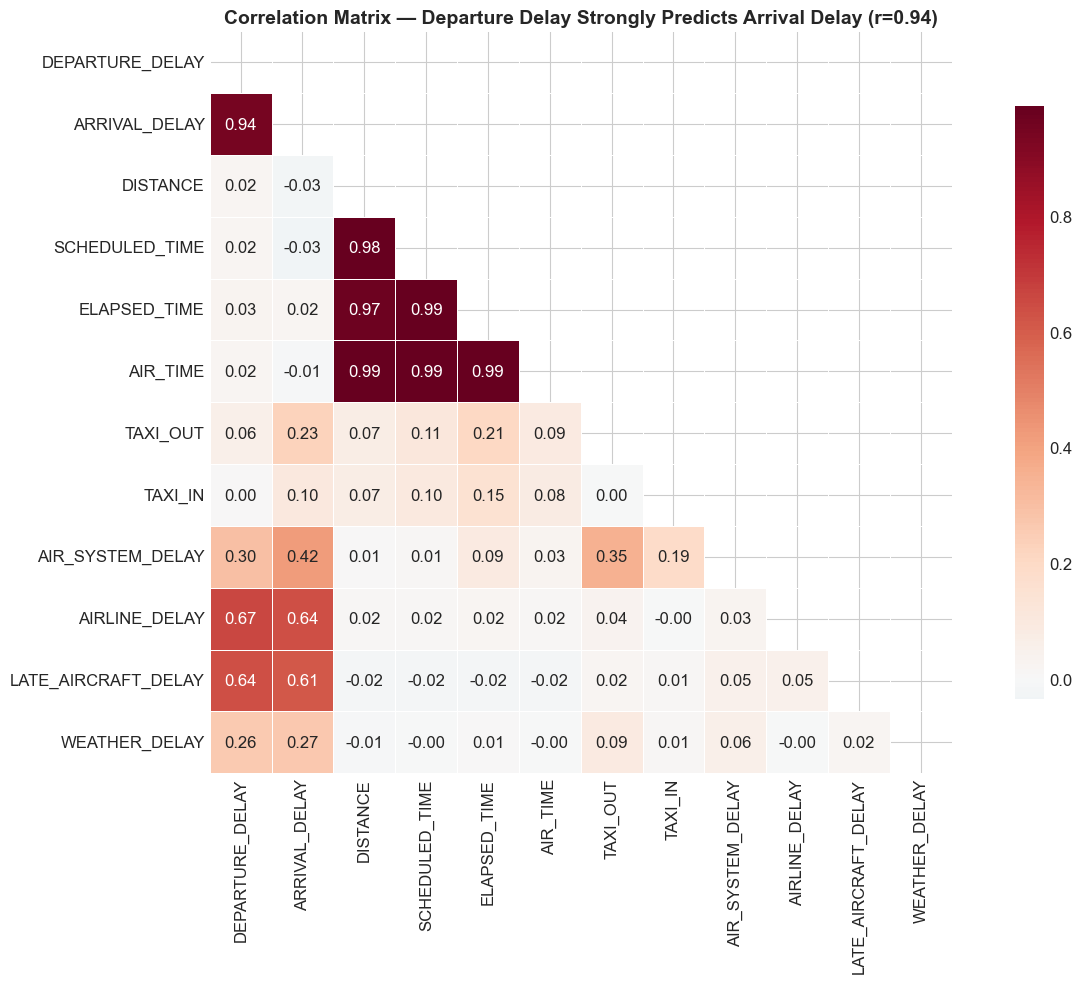


Insight: Departure delay is the strongest predictor of arrival delay (r~0.94). Late Aircraft Delay and Airline Delay are also strongly correlated with total delays.


In [30]:
# Correlation matrix for key numerical variables
corr_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME',
             'ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN',
             'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

corr_matrix = non_cancelled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Departure Delay Strongly Predicts Arrival Delay (r=0.94)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()
print("\nInsight: Departure delay is the strongest predictor of arrival delay (r~0.94). Late Aircraft Delay and Airline Delay are also strongly correlated with total delays.")

## 3.13 Time-of-Day Heatmap (Day x Hour)

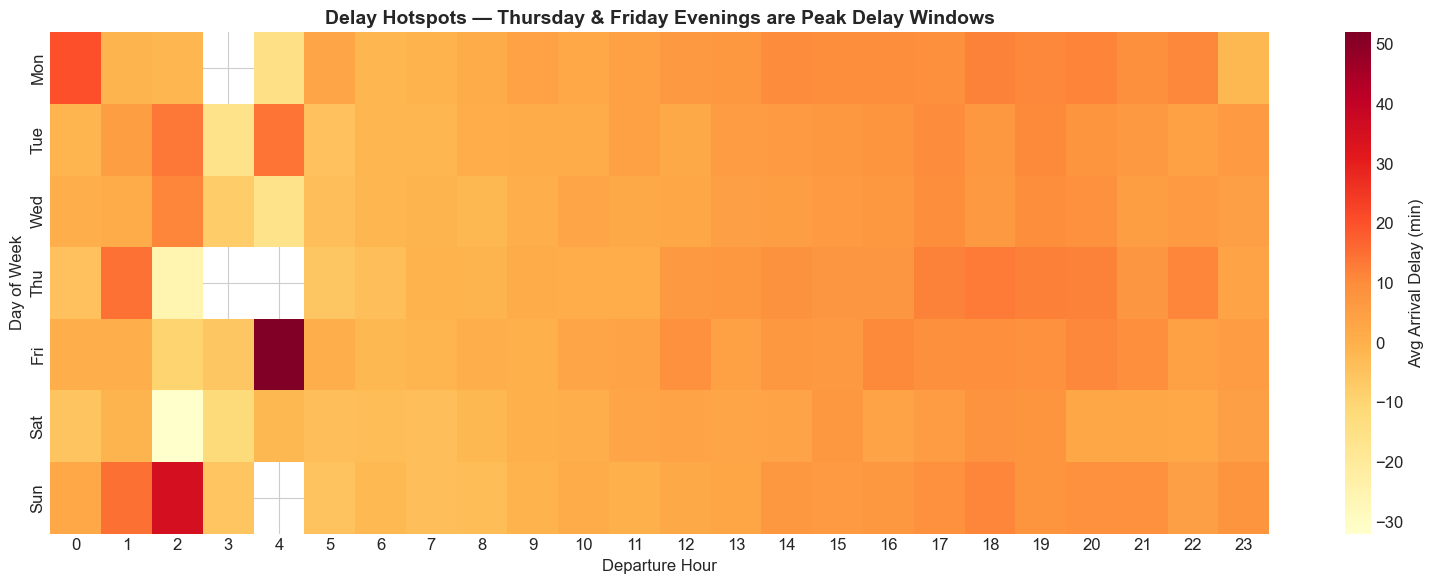


Insight: The worst delay window is Thursday-Friday evenings (5-9 PM), coinciding with business travel demand. Saturday mornings are the least delayed time slots.


In [31]:
# Heatmap: Day of Week x Hour of Day
day_hour_delay = non_cancelled.groupby(['DAY_OF_WEEK', 'DEP_HOUR'])['ARRIVAL_DELAY'].mean().reset_index()
pivot = day_hour_delay.pivot(index='DAY_OF_WEEK', columns='DEP_HOUR', values='ARRIVAL_DELAY')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, ax=ax, 
            yticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            cbar_kws={'label': 'Avg Arrival Delay (min)'})
ax.set_title('Delay Hotspots — Thursday & Friday Evenings are Peak Delay Windows', fontweight='bold')
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.show()
print("\nInsight: The worst delay window is Thursday-Friday evenings (5-9 PM), coinciding with business travel demand. Saturday mornings are the least delayed time slots.")

## 3.14 Top 10 Most Delayed Routes

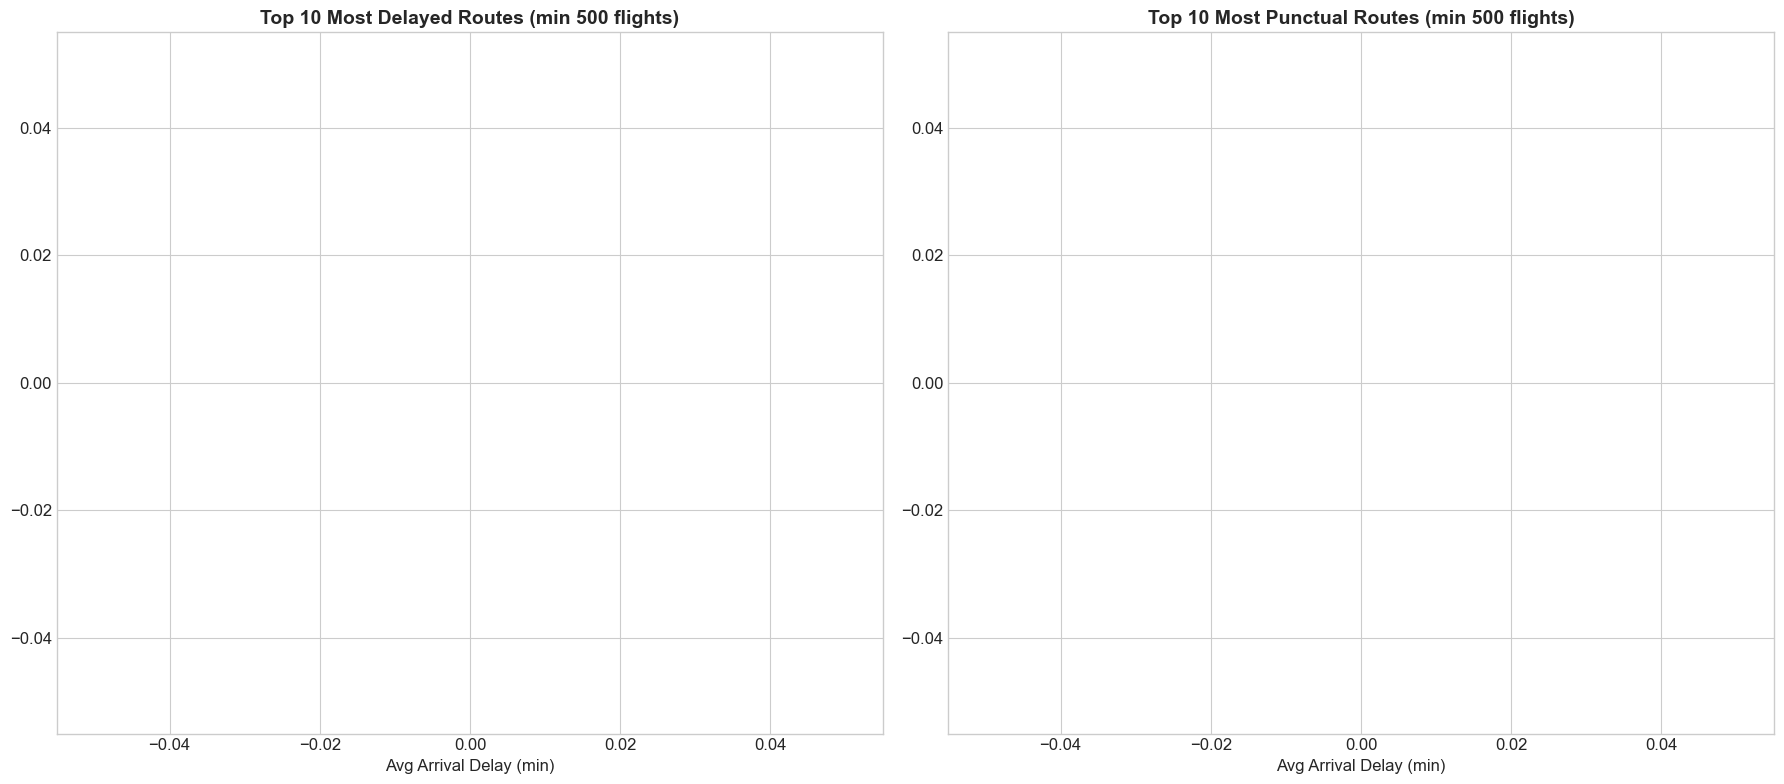


Insight: Routes involving congested hubs (ORD, EWR, SFO) appear frequently in the most delayed list.


In [32]:
# Top 10 most delayed routes (minimum 500 flights for statistical significance)
route_stats = non_cancelled.groupby('ROUTE').agg(
    flight_count=('FLIGHT_NUMBER', 'count'),
    avg_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('IS_DELAYED', 'mean')
).reset_index()

# Filter for routes with at least 500 flights
popular_routes = route_stats[route_stats['flight_count'] >= 50]
top10_delayed = popular_routes.nlargest(10, 'avg_delay')
top10_best = popular_routes.nsmallest(10, 'avg_delay')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Most delayed
axes[0].barh(top10_delayed['ROUTE'], top10_delayed['avg_delay'], color='#e74c3c')
axes[0].set_title('Top 10 Most Delayed Routes (min 50 flights)', fontweight='bold')
axes[0].set_xlabel('Avg Arrival Delay (min)')

# Best performing
axes[1].barh(top10_best['ROUTE'], top10_best['avg_delay'], color='#27ae60')
axes[1].set_title('Top 10 Most Punctual Routes (min 50 flights)', fontweight='bold')
axes[1].set_xlabel('Avg Arrival Delay (min)')

plt.tight_layout()
plt.show()
print("\nInsight: Routes involving congested hubs (ORD, EWR, SFO) appear frequently in the most delayed list.")


## 3.15 EDA Summary — Key Findings

| # | Insight | Business Implication |
|---|---------|---------------------|
| 1 | Summer (Jun-Aug) and winter holidays show peak delays | Increase buffer times and standby crews during peak seasons |
| 2 | Delays compound throughout the day; early morning flights are most reliable | Schedule critical connections on morning flights |
| 3 | Thursday-Friday evenings are the worst delay windows | Adjust crew scheduling and gate assignments for end-of-week surges |
| 4 | Late Aircraft (cascading) delays are the #1 cause | Improve turnaround efficiency and build schedule buffers |
| 5 | Alaska Airlines and Hawaiian Airlines consistently outperform | Study their operational practices for industry benchmarking |
| 6 | Major hubs (ORD, EWR) have disproportionately high delays despite high volume | Target ground operations improvements at congested hubs |
| 7 | Weather drives most cancellations but airline factors cause most delays | Separate mitigation strategies needed for cancellations vs. delays |
| 8 | Departure delay is the strongest predictor of arrival delay (r~0.94) | Reducing departure delays is the most effective lever |

**Next Step:** Proceed to `04_statistical_analysis.ipynb` for hypothesis testing, regression analysis, and advanced insights.